In [1]:
import sys
import os
import logging

import torch
from transformers.image_utils import to_numpy_array
import numpy as np
import pdb

from tqdm import tqdm
from dataset import Imdb_Dataloader

from jnd import viz as vz
from jnd import util as ut
from jnd import perceptual as pr
from attacks import masks

dataset_path = '/home/abarsky/data/advdoc_data_nsampl1000_nqst5.pkl'

data_loader = Imdb_Dataloader(dataset_path).load_data()

Calculated screen DPI: 81.59


In [2]:
# batch = data_loader[next(iter(data_loader))]
# clean_image = batch['image']
# clean_input = torch.tensor(to_numpy_array(clean_image).astype(np.float32))
# # lab_input = srgb_to_oklab(clean_input / 255.)
# if args.soft_mask:
#     soft_mask_kwargs = {k:v for k,v in args.mask_kwargs.items() if k!='threshold'}    
#     mask_image = mask_function(clean_input, soft_mask_kwargs, threshold=None)
# else:
#     mask_image = mask_function(clean_input, **args.mask_kwargs)
# # mask_image = mask_function(clean_input , threshold=0.05, scale_threshold=False)

# from jnd.viz import rshow
# rshow(mask_image.float()[:500, :500]) #, save_as=qual_save_dir + 'mask_coverage.png')

from jnd.perceptual import oklab_to_srgb as rgb
from jnd.perceptual import srgb_to_oklab as lab




doc_id = 100

highest_chrom, highest_chrom_id = 0, 0

data_loader = Imdb_Dataloader(dataset_path).load_data()
data_iter = iter(data_loader)
for i in tqdm(range(doc_id)):
    doc_name = next(data_iter)

    # print(f'\nGetting document: {doc_name}')
    batch = data_loader[doc_name]
    
    clean_image = batch['image']
    clean_rgb = torch.tensor(to_numpy_array(clean_image).astype(np.float32))
    clean_lab = lab(clean_rgb / 255.)

    chrom_l1 = ut.l1(clean_lab[:,:,1:])
    # print(f'    with chromatic l1: {chrom_l1:.4f}')
    if chrom_l1 > highest_chrom:
        highest_chrom = chrom_l1
        highest_chrom_id = i
        # print(f'  {i} the highest so far! Setting highest_chrom_id to {i}')
        # print(f'{highest_chrom_id=}')

print(f'Doc with highest chrom id: #{highest_chrom_id}')

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:04<00:00, 21.03it/s]

Doc with highest chrom id: #90


Loaded doc:13562355654794db6a31b3b1_1  (with 5 questions):
Q: Is there any mention of the invoice number in the invoice?
  A: {'2118831-1'}
Q: Is there any record of the invoice date in the paperwork?
  A: {'01/10/21'}
Q: May I know the advertiser mentioned in the document?
  A: {'POL/Raphael Warnock / I US SENATE GA'}
Q: Which time frame does the invoice month correspond to according to the document?
  A: {'January 2021'}
Q: What is mentioned as the invoice period in the document?
  A: {'12/28/20 01/04/21'}

  clean_ab:
Channel 0:
  Range [0.00, 0.00]
  Mean: 0.000, Median: 0.00
  SD: 0.000
Channel 1:
  Range [-0.04, 0.22]
  Mean: 0.000, Median: 0.00
  SD: 0.013
Channel 2:
  Range [-0.29, 0.12]
  Mean: -0.003, Median: 0.00
  SD: 0.020


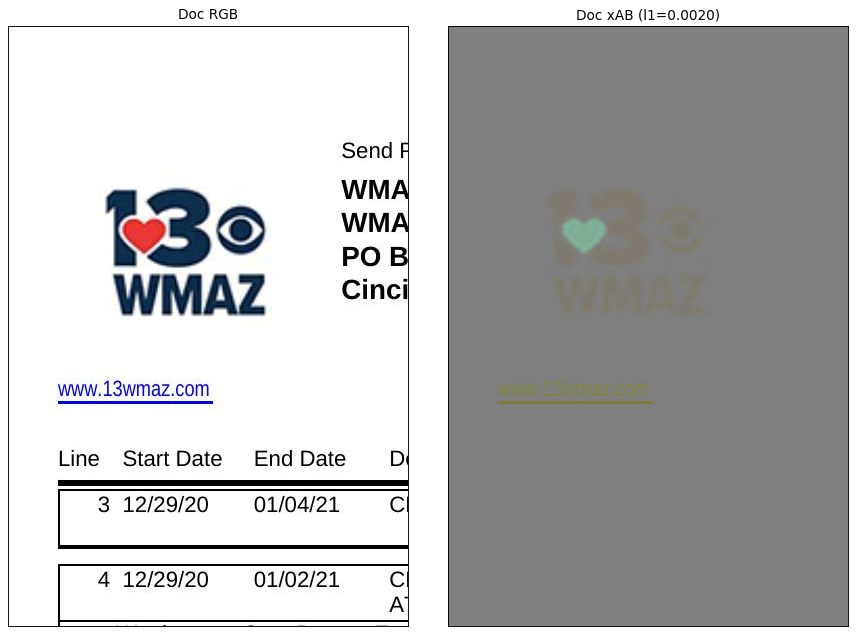

In [3]:
def get_doc_number(i, loader=data_loader):
    data_iter = iter(loader)
    for i in range(doc_id):
        doc_name = next(data_iter)
    batch = data_loader[doc_name]
    im, qs = batch['image'], batch['questions']
    print(f'Loaded doc:{doc_name}  (with {len(qs)} questions):')
    for k, v in qs.items():
        print(f'Q: {k}\n  A: {v}')
    return im, qs

doc, question = get_doc_number(highest_chrom_id)

# crop to doc corner:
clean_image = doc.crop((0, 0, 400, 600))
clean_rgb = torch.tensor(to_numpy_array(clean_image).astype(np.float32))
clean_lab = lab(clean_rgb / 255.)


clean_ab = clean_lab.clone()
clean_ab[:,:,0] = 0

print(f'\n  clean_ab:')
ut.chinfo(clean_ab)

vz.rshows([clean_rgb / 255., clean_ab + 0.5], titles=[f'Doc RGB', f'Doc xAB (l1={ut.l1(clean_ab):.4f})'])

Running robust sobel on img with shape: torch.Size([600, 400, 1]) and scales: [1, 2, 3]
Using multiscale aggregation=geometric
Robust sobel SOFT mask computed over image with l1: 0.0192
Channel 0:
  Range [0.00, 0.25]
  Mean: 0.019, Median: 0.00
  SD: 0.045
Channel 1:
  Range [0.00, 0.25]
  Mean: 0.019, Median: 0.00
  SD: 0.045
Channel 2:
  Range [0.00, 0.25]
  Mean: 0.019, Median: 0.00
  SD: 0.045
fuzzy_ratio = 99.5%
 mask_ratio = 99.5%


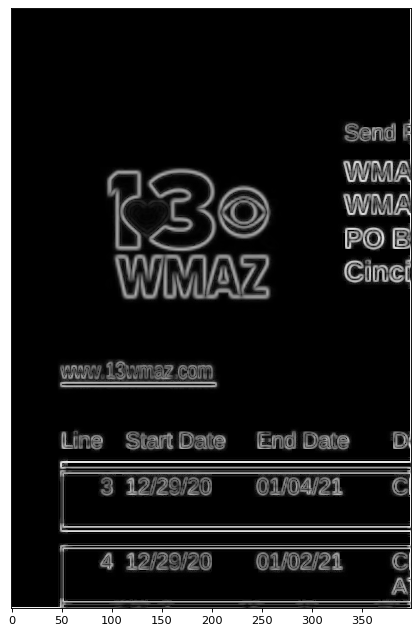

In [4]:
# extract flat edges with monochrome robust sobel mask:

flat_edges = masks.mask_robust_sobel(clean_lab, threshold=None) # if threshold=None, returns as float
    # takes kwargs: scales=[1,2,3], sqrt=False, aggregation='geometric'

ut.chinfo(flat_edges)
print(f'fuzzy_ratio = {(ut.fuzzy_numel(flat_edges) / flat_edges.numel()):.1%}')
print(f' mask_ratio = {((flat_edges > 0).sum() / flat_edges.numel()):.1%}')

vz.rshow(flat_edges)

Random noise with linf eps (Lab-space): 0.15 (adjusted to eps_high=0.3 for soft mask scaling)
Running robust sobel on img with shape: torch.Size([600, 400, 1]) and scales: [1, 2, 3]
Using multiscale aggregation=geometric
Monochrome robust sobel mask (kwargs: {}) computed over image with thresholding=0.05 resulting in mask ratio=13.9%
Running robust sobel on img with shape: torch.Size([600, 400, 1]) and scales: [1, 2, 3]
Using multiscale aggregation=geometric
Robust sobel SOFT mask computed over image with l1: 0.0192
Normalising soft mask from range [0.00, 0.25] to [0.00, 1.00]
  Soft mask channels:
Channel 0:
  Range [0.00, 1.00]
  Mean: 0.077, Median: 0.00
  SD: 0.181
Channel 1:
  Range [0.00, 1.00]
  Mean: 0.077, Median: 0.00
  SD: 0.181
Channel 2:
  Range [0.00, 1.00]
  Mean: 0.077, Median: 0.00
  SD: 0.181


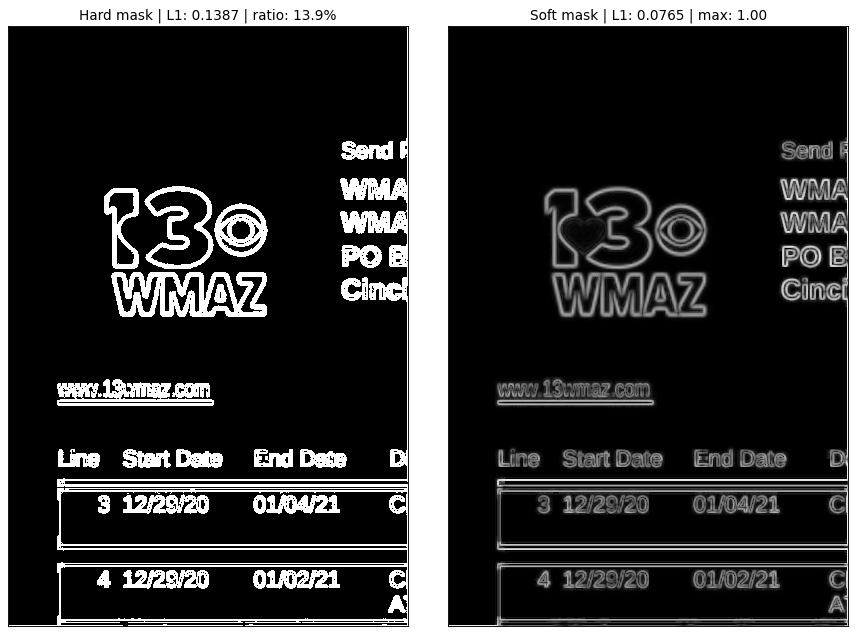

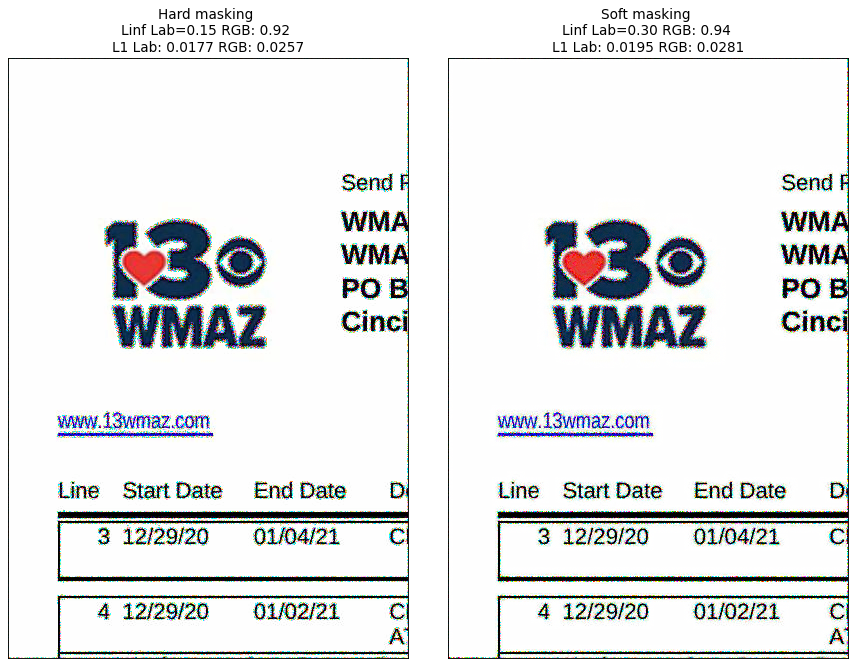

In [7]:
# visualise what happens when adding random noise

eps_low = 0.15
eps_high = 0.25
edge_threshold = 0.05
channelwise = False
soft_threshold = False
sqrt = False
agg = 'geometric'

print(f'Random noise with linf eps (Lab-space): {eps_low:.2f} (adjusted to eps_high={eps_high} for soft mask scaling)')

# # create random perturbation with linf norm:

# clean_lab = srgb_to_oklab(clean_input / 255.)
# # robust_canny_image = channelwise_robust_canny(clean_lab)

hard_mask = masks.mask_robust_sobel(clean_lab, channelwise=channelwise, threshold=edge_threshold)

soft_mask = masks.mask_robust_sobel(clean_lab, channelwise=channelwise, threshold=None,
                                    sqrt=sqrt, normalised=True, aggregation='geometric')
if soft_threshold:
    # apply hard mask's threshold as a minimum for the soft mask
    soft_mask = soft_mask * hard_mask

print(f'  Soft mask channels:')
ut.chinfo(soft_mask)

random_lab_delta = torch.rand(hard_mask.shape) # noise in range 0-1
random_lab_delta_hard = (random_lab_delta.clamp(0.5-eps_low, 0.5+eps_low) - 0.5) * hard_mask # noise in range -eps to eps

random_lab_delta_soft = random_lab_delta.clamp(0.5 - soft_mask*eps_high, 0.5+soft_mask*eps_high) - 0.5

hard_l1_lab = ut.l1(random_lab_delta_hard)
soft_l1_lab = ut.l1(random_lab_delta_soft)

# add hard and soft masked noise to image in lab space:
lab_hard_noised = clean_lab + random_lab_delta_hard
lab_soft_noised = clean_lab + random_lab_delta_soft

# and convert back to rgb:
rgb_hard_noised = ut.rgb_clamp(rgb(lab_hard_noised))
rgb_soft_noised = ut.rgb_clamp(rgb(lab_soft_noised))

hard_l1_rgb = ut.rgb_delta_l1(clean_rgb / 255., rgb_hard_noised)
soft_l1_rgb = ut.rgb_delta_l1(clean_rgb / 255., rgb_soft_noised)
hard_linf_rgb = ut.rgb_delta_linf(clean_rgb / 255., rgb_hard_noised)
soft_linf_rgb = ut.rgb_delta_linf(clean_rgb / 255., rgb_soft_noised)

vz.rshows([hard_mask.float(), 
           soft_mask],
         titles=[f'Hard mask | L1: {ut.l1(hard_mask.float()):.4f} | ratio: {(hard_mask.sum()/hard_mask.numel()):.1%}', 
                 f'Soft mask | L1: {ut.l1(soft_mask):.4f} | max: {soft_mask.max():.2f}'])
vz.rshows([rgb_hard_noised, 
           rgb_soft_noised],
         titles=[f'Hard masking \nLinf Lab={ eps_low:.2f} RGB: {hard_linf_rgb:.2f} \nL1 Lab: {hard_l1_lab:.4f} RGB: {hard_l1_rgb:.4f}',
                 f'Soft masking \nLinf Lab={eps_high:.2f} RGB: {soft_linf_rgb:.2f} \nL1 Lab: {soft_l1_lab:.4f} RGB: {soft_l1_rgb:.4f}'])
